# Hessian-only analysis of ordinary minimisations

This notebook analyses the non-bootstrap `*_results_i.root` files.  Each ROOT
file contains (N) independent random-start minimisations of the same data.  It
selects the converged global minimum and uses the Hessian/covariance stored for
that exact entry.  The spread over random starts is shown only as a convergence
diagnostic and is never used as a statistical uncertainty.

Moment and (R) uncertainties are propagated from the amplitude covariance.
The moments remain on the horizontal axis in every moment comparison.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import ROOT

try:
    from IPython.display import display
except Exception:
    def display(value):
        print(value)

# A working LaTeX installation is required, as requested for all plots.
mpl.rcParams["text.usetex"] = False
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "lines.linewidth": 2.0,
    "axes.linewidth": 1.4,
    "savefig.dpi": 1200,
})

COLORS = {
    "fit": "#0072B2",
    "official": "#D55E00",
    "neutral": "#333333",
    "accent": "#009E73",
}

MAG_RE = re.compile(r"^[ab]_[TL]_\d+_(?:m?\d+)$")
PHASE_RE = re.compile(r"^[ab]phi_[TL]_\d+_(?:m?\d+)$")
RESULT_RE = re.compile(
    r"(?P<beam>El|Mu)(?P<particle>Rho|Omega|Phi)_results_(?P<bin>\d+)$"
)


def style_axis(ax, grid=False):
    ax.minorticks_on()
    ax.tick_params(which="major", direction="in", top=True, right=True,
                   length=7, width=1.2, pad=5)
    ax.tick_params(which="minor", direction="in", top=True, right=True,
                   length=3.5, width=0.9)
    if grid:
        ax.grid(True, color="0.90", linewidth=0.8, zorder=0)
    for spine in ax.spines.values():
        spine.set_linewidth(1.3)


def save_figure(fig, output_path, show=True):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)
    print(f"Saved {output_path.resolve()}")


def dataset_metadata(path):
    path = Path(path)
    match = RESULT_RE.match(path.stem)
    if not match:
        return {"key": path.stem, "title": path.stem, "bin": None}
    info = match.groupdict()
    beam = {"El": r"e^-", "Mu": r"\mu^-"}[info["beam"]]
    particle = {"Rho": r"\rho^0", "Omega": r"\omega", "Phi": r"\phi"}[info["particle"]]
    return {
        "key": path.stem,
        "title": rf"${beam}{particle}$, bin {info['bin']}",
        "beam": info["beam"],
        "particle": info["particle"],
        "bin": int(info["bin"]),
    }


def list_root_branches(path, tree_name="fitResults"):
    path = Path(path).expanduser().resolve()
    root_file = ROOT.TFile.Open(str(path), "READ")
    if not root_file or root_file.IsZombie():
        raise OSError(f"Could not open ROOT file: {path}")
    try:
        tree = root_file.Get(tree_name)
        if not tree:
            raise KeyError(f"Tree {tree_name!r} not found in {path}")
        return [str(branch.GetName()) for branch in tree.GetListOfBranches()]
    finally:
        root_file.Close()


def read_fit_file(path, tree_name="fitResults"):
    path = Path(path).expanduser().resolve()
    if not path.exists():
        raise FileNotFoundError(path)
    branches = list_root_branches(path, tree_name)
    rdf = ROOT.RDataFrame(tree_name, str(path))
    arrays = rdf.AsNumpy(columns=branches)
    frame = pd.DataFrame({name: np.asarray(values) for name, values in arrays.items()})
    if frame.empty:
        raise RuntimeError(f"No minimisation entries in {path}")
    return frame


def objective_column(frame):
    for candidate in ("chi2", "val", "log_val"):
        if candidate in frame:
            return candidate
    raise KeyError("No objective branch found (expected chi2, val, or log_val)")


def select_best_minimum(frame, require_accurate_covariance=True):
    objective = objective_column(frame)
    values = pd.to_numeric(frame[objective], errors="coerce").to_numpy(dtype=float)
    usable = np.isfinite(values)
    if "fit_ok" in frame:
        usable &= frame["fit_ok"].astype(bool).to_numpy()
    if "status" in frame:
        usable &= frame["status"].to_numpy() == 0
    if not np.any(usable):
        raise RuntimeError("No converged minimisation has a finite objective value")
    candidates = np.flatnonzero(usable)
    index = int(candidates[np.argmin(values[candidates])])
    row = frame.iloc[index].copy()

    required = ["hesse_ok", "cov_status"]
    missing = [name for name in required if name not in frame]
    if missing:
        raise KeyError(
            "This results file predates Hessian persistence; missing " + ", ".join(missing)
        )
    if not bool(row["hesse_ok"]):
        raise RuntimeError(f"The global minimum at entry {index} has no valid HESSE result")
    minimum_cov_status = 2 if require_accurate_covariance else 1
    if int(row["cov_status"]) < minimum_cov_status:
        raise RuntimeError(
            f"The global minimum at entry {index} has covariance status "
            f"{int(row['cov_status'])}; require >= {minimum_cov_status}"
        )
    return index, row, objective


def magnitude_parameters(columns):
    return [name for name in columns if MAG_RE.match(name)]


def phase_for_magnitude(name):
    return name[0] + "phi" + name[1:]


def amplitude_pairs(columns):
    available = set(columns)
    return [(name, phase_for_magnitude(name))
            for name in magnitude_parameters(columns)
            if phase_for_magnitude(name) in available]


def covariance_value(row, first, second):
    candidates = [f"cov__{first}__{second}", f"cov__{second}__{first}"]
    for branch in candidates:
        if branch in row.index:
            return float(row[branch])
    if first == second and f"err__{first}" in row.index:
        return float(row[f"err__{first}"]) ** 2
    return np.nan


def covariance_matrix(row, parameters):
    matrix = np.full((len(parameters), len(parameters)), np.nan)
    for i, first in enumerate(parameters):
        for j, second in enumerate(parameters):
            matrix[i, j] = covariance_value(row, first, second)
    return matrix


def transformed_argand_covariance(magnitude, phase, covariance_mag_phase):
    jacobian = np.array([
        [np.cos(phase), -magnitude * np.sin(phase)],
        [np.sin(phase),  magnitude * np.cos(phase)],
    ])
    return jacobian @ covariance_mag_phase @ jacobian.T


def add_covariance_ellipse(ax, centre, covariance, color, n_sigma=1.0,
                           alpha=0.22, linewidth=1.8):
    covariance = np.asarray(covariance, dtype=float)
    if covariance.shape != (2, 2) or not np.isfinite(covariance).all():
        return
    covariance = 0.5 * (covariance + covariance.T)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    if np.any(eigenvalues < -1e-12):
        return
    eigenvalues = np.clip(eigenvalues, 0.0, None)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    width, height = 2.0 * n_sigma * np.sqrt(eigenvalues)
    ellipse = Ellipse(centre, width, height, angle=angle,
                      facecolor=color, edgecolor=color, alpha=alpha,
                      linewidth=linewidth)
    ax.add_patch(ellipse)


def wave_label(name):
    match = re.match(r"(?P<refl>[ab])_(?P<pol>[TL])_(?P<ell>\d+)_(?P<m>m?\d+)", name)
    if not match:
        return name.replace("_", r"_")
    info = match.groupdict()
    reflection = "+" if info["refl"] == "a" else "-"
    wave = {"0": "S", "1": "P"}.get(info["ell"], rf"\ell={info['ell']}")
    m = info["m"].replace("m", "-")
    return rf"${wave}^{{{reflection}}}_{{\mathrm{{{info['pol']}}}{m}}}$"


def discover_result_files(root_dir):
    root_dir = Path(root_dir).expanduser()
    files = []
    for beam in ("El", "Mu"):
        for particle in ("Rho", "Omega", "Phi"):
            files.extend(root_dir.glob(f"{beam}{particle}_results_*.root"))
    return sorted({path.resolve() for path in files}, key=lambda path: path.name)


In [2]:
ROOT_DIR = Path(
    "~/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/OutputFiles"
).expanduser()
TREE_NAME = "fitResults"
OUT_DIR = Path("outputs/hessian_only_analysis")

# Set to an explicit list of result files to override discovery.
ROOT_FILES = None
REQUIRE_ACCURATE_COVARIANCE = True

if ROOT_FILES is None:
    ROOT_FILES = discover_result_files(ROOT_DIR)
else:
    ROOT_FILES = [Path(path).expanduser().resolve() for path in ROOT_FILES]

if not ROOT_FILES:
    raise FileNotFoundError(
        f"No El/Mu rho, omega, or phi *_results_*.root files found in {ROOT_DIR}"
    )

print(f"Discovered {len(ROOT_FILES)} non-bootstrap result files:")
for root_file in ROOT_FILES:
    print(" -", root_file.name)


Discovered 17 non-bootstrap result files:
 - ElOmega_results_0.root
 - ElOmega_results_1.root
 - ElOmega_results_2.root
 - ElPhi_results_0.root
 - ElPhi_results_1.root
 - ElPhi_results_2.root
 - ElRho_results_0.root
 - ElRho_results_1.root
 - ElRho_results_2.root
 - ElRho_results_3.root
 - MuOmega_results_0.root
 - MuOmega_results_1.root
 - MuOmega_results_2.root
 - MuRho_results_0.root
 - MuRho_results_1.root
 - MuRho_results_2.root
 - MuRho_results_3.root


In [3]:
OFFICIAL_MOMENTS_BY_DATASET = {'ElRho_results_0': {'H04_2_0': (0.0188, 0.0795718543205),
                     'H04_2_1': (0.0387979380895, 0.0476789261624),
                     'H04_2_2': (0.0235151015307, 0.0241991735396),
                     'H_1_0_0': (0.264, 0.128716743278),
                     'H_1_2_0': (0.012, 0.0383916657622),
                     'H_1_2_1': (0.051268703904, 0.0753870015321),
                     'H_1_2_2': (0.277282238883, 0.0530358369407),
                     'H_2_2_1': (-0.0318697348593, 0.0280570846668),
                     'H_2_2_2': (-0.288059993751, 0.0416269143704),
                     'H_3_2_1': (-0.00277128129211, 0.0578826398845),
                     'H_3_2_2': (0.0205757138394, 0.050921115463),
                     'H_5_0_0': (-0.182, 0.119348229983),
                     'H_5_2_0': (-0.1088, 0.0446425805706),
                     'H_5_2_1': (-0.209231737554, 0.0529452547449),
                     'H_5_2_2': (0.00881816307402, 0.0215109274556),
                     'H_6_2_1': (0.206460456262, 0.0249799919936),
                     'H_6_2_2': (-0.0107777548682, 0.0160698475413),
                     'H_7_2_1': (-0.109465611038, 0.0954484153876),
                     'H_7_2_2': (-0.00293938769134, 0.0791454357496),
                     'H_8_0_0': (-0.12, 0.270916961448),
                     'H_8_2_0': (-0.0024, 0.0790948797331),
                     'H_8_2_1': (-0.0554256258422, 0.0615012195001),
                     'H_8_2_2': (0.0127373466625, 0.0612509591762)},
 'ElRho_results_1': {'H04_2_0': (0.0416, 0.0253140277317),
                     'H04_2_1': (0.0401835787356, 0.0105527247666),
                     'H04_2_2': (0.0137171425596, 0.0138564064606),
                     'H_1_0_0': (0.114, 0.103923048454),
                     'H_1_2_0': (-0.036, 0.0328487442682),
                     'H_1_2_1': (0.0595825477804, 0.0185903200618),
                     'H_1_2_2': (0.256706525044, 0.0293938769134),
                     'H_2_2_1': (-0.0304840942132, 0.0299759903923),
                     'H_2_2_2': (-0.249847953764, 0.0266533299983),
                     'H_3_2_1': (0.0568112664883, 0.036686782361),
                     'H_3_2_2': (0, 0.0325699247773),
                     'H_5_0_0': (-0.144, 0.0588557558782),
                     'H_5_2_0': (-0.084, 0.0203960780544),
                     'H_5_2_1': (-0.236944550475, 0.00969948452239),
                     'H_5_2_2': (0.00783836717691, 0.00903327183251),
                     'H_6_2_1': (0.231401987891, 0.0105527247666),
                     'H_6_2_2': (0.00195959179423, 0.00969948452239),
                     'H_7_2_1': (-0.127478939437, 0.054447038487),
                     'H_7_2_2': (0.0225353056336, 0.0563276131218),
                     'H_8_0_0': (-0.304, 0.248322371123),
                     'H_8_2_0': (0.0128, 0.0771201659749),
                     'H_8_2_1': (-0.0277128129211, 0.0443621460256),
                     'H_8_2_2': (0.0705453045922, 0.0530358369407)},
 'ElRho_results_2': {'H04_2_0': (0.0764, 0.0297106041675),
                     'H04_2_1': (0.0484974226119, 0.018066543665),
                     'H04_2_2': (0.0186161220452, 0.010229369482),
                     'H_1_0_0': (0.078, 0.0888594395661),
                     'H_1_2_0': (-0.024, 0.0285657137142),
                     'H_1_2_1': (0.049883063258, 0.0235151015307),
                     'H_1_2_2': (0.268464075809, 0.029991998933),
                     'H_2_2_1': (-0.00692820323028, 0.0371806401236),
                     'H_2_2_2': (-0.23417121941, 0.0198393548282),
                     'H_3_2_1': (0.102537407808, 0.0353270434653),
                     'H_3_2_2': (-0.0303736728105, 0.0320948594015),
                     'H_5_0_0': (-0.082, 0.0696850055607),
                     'H_5_2_0': (-0.052, 0.0218064210727),
                     'H_5_2_1': (-0.223088144015, 0.00999199679744),
                     'H_5_2_2': (-0.0127373466625, 0.00746190324247),
                     'H_6_2_1': (0.231401987891, 0.0108221994068),
                     'H_6_2_2': (0.00195959179423, 0.00789936706325),
                     'H_7_2_1': (-0.0540399851961, 0.0501900388523),
                     'H_7_2_2': (-0.00489897948557, 0.0547722557505),
                     'H_8_0_0': (-0.312, 0.248233760798),
                     'H_8_2_0': (-0.0024, 0.0779291986357),
                     'H_8_2_1': (-0.102537407808, 0.047193219852),
                     'H_8_2_2': (-0.017636326148, 0.0530539348211)},
 'ElRho_results_3': {'H04_2_0': (0.1448, 0.0213653925777),
                     'H04_2_1': (0.0360266567974, 0.0105527247666),
                     'H04_2_2': (-0.000979795897113, 0.011171392035),
                     'H_1_0_0': (-0.002, 0.0924337600663),
                     'H_1_2_0': (-0.044, 0.0299759903923),
                     'H_1_2_1': (0.0124707658145, 0.0227261963381),
                     'H_1_2_2': (0.199878363011, 0.0203882318998),
                     'H_2_2_1': (-0.0304840942132, 0.0211508865062),
                     'H_2_2_2': (-0.193019791731, 0.0203882318998),
                     'H_3_2_1': (-0.0665107510106, 0.034278856457),
                     'H_3_2_2': (-0.0254746933249, 0.0278682615174),
                     'H_5_0_0': (-0.218, 0.0759473501842),
                     'H_5_2_0': (-0.1376, 0.0190326036054),
                     'H_5_2_1': (-0.195375331094, 0.0138564064606),
                     'H_5_2_2': (0.0195959179423, 0.010415373253),
                     'H_6_2_1': (0.216159940785, 0.0161592079014),
                     'H_6_2_2': (-0.00979795897113, 0.00969948452239),
                     'H_7_2_1': (-0.259114800812, 0.0533066599967),
                     'H_7_2_2': (-0.106797752785, 0.0462168800332),
                     'H_8_0_0': (-0.012, 0.223436791957),
                     'H_8_2_0': (-0.0096, 0.0747518561642),
                     'H_8_2_1': (-0.135792783313, 0.0448785026488),
                     'H_8_2_2': (0.00391918358845, 0.0461753180823)},
 'ElPhi_results_0': {'H04_2_0': (-0.080956, 0.0235714121766),
                     'H04_2_1': (-0.0248168239708, 0.0347948961775),
                     'H04_2_2': (0.00548685702383, 0.0198526983556),
                     'H_1_0_0': (0.00508, 0.117140223664),
                     'H_1_2_0': (-0.049304, 0.0289332218738),
                     'H_1_2_1': (-0.027227838695, 0.0571445409466),
                     'H_1_2_2': (0.312731254441, 0.0275697660491),
                     'H_2_2_1': (0.0107802842263, 0.0455515721792),
                     'H_2_2_2': (-0.271452453295, 0.0301922798079),
                     'H_3_2_1': (-0.0106971457875, 0.0930031844616),
                     'H_3_2_2': (-0.0813622512963, 0.102193838405),
                     'H_5_0_0': (0.111, 0.127967339583),
                     'H_5_2_0': (-0.000984, 0.032635298681),
                     'H_5_2_1': (-0.236016171243, 0.021435435335),
                     'H_5_2_2': (0.0122376507549, 0.0178032473442),
                     'H_6_2_1': (0.203384334028, 0.013785871028),
                     'H_6_2_2': (-0.0267778218681, 0.0173487078481),
                     'H_7_2_1': (-0.0356386774165, 0.122755850565),
                     'H_7_2_2': (-0.122229538165, 0.154255333263),
                     'H_8_0_0': (0.25848, 0.528252178036),
                     'H_8_2_0': (-0.225792, 0.144988018264),
                     'H_8_2_1': (-0.11744690116, 0.110366116539),
                     'H_8_2_2': (-0.236150407122, 0.133736073338)},
 'ElPhi_results_1': {'H04_2_0': (0.011024, 0.0260313884378),
                     'H04_2_1': (-0.00609681884264, 0.0262028163372),
                     'H04_2_2': (-0.025455097407, 0.0199851969217),
                     'H_1_0_0': (-0.11162, 0.128256731597),
                     'H_1_2_0': (0.025696, 0.0331736049292),
                     'H_1_2_1': (0.0127478939437, 0.0684570260528),
                     'H_1_2_2': (0.274401638946, 0.0284504115963),
                     'H_2_2_1': (0.0226136553436, 0.0270738226337),
                     'H_2_2_2': (-0.261037222909, 0.0389263920753),
                     'H_3_2_1': (-0.133686609531, 0.0789221708774),
                     'H_3_2_2': (-0.0867609266894, 0.0773494669148),
                     'H_5_0_0': (-0.0555, 0.117178632865),
                     'H_5_2_0': (-0.023208, 0.0301015178355),
                     'H_5_2_1': (-0.224584635913, 0.0170000941174),
                     'H_5_2_2': (0.00173423873789, 0.0176913185489),
                     'H_6_2_1': (0.232801484944, 0.0150564633297),
                     'H_6_2_2': (-0.0215163179006, 0.0155534937554),
                     'H_7_2_1': (-0.230875444446, 0.0947562197642),
                     'H_7_2_2': (-0.0781191268768, 0.116574073962),
                     'H_8_0_0': (0.39378, 0.470596835093),
                     'H_8_2_0': (0.173064, 0.136414844471),
                     'H_8_2_1': (-0.14073952042, 0.103239234402),
                     'H_8_2_2': (-0.155718961928, 0.115051718736)},
 'ElPhi_results_2': {'H04_2_0': (0.083612, 0.032927940962),
                     'H04_2_1': (-0.0250662392871, 0.0305986164393),
                     'H04_2_2': (0.0256608545454, 0.0221436929169),
                     'H_1_0_0': (-0.03046, 0.137448208428),
                     'H_1_2_0': (-0.016456, 0.0392135046126),
                     'H_1_2_1': (-0.00579197790051, 0.0384706549983),
                     'H_1_2_2': (0.258793490305, 0.0306185904313),
                     'H_2_2_1': (0.00613838806202, 0.0447971084781),
                     'H_2_2_2': (-0.226597397125, 0.0236130831532),
                     'H_3_2_1': (0.0612453165556, 0.0717897142493),
                     'H_3_2_2': (0.0164801669894, 0.0668793758344),
                     'H_5_0_0': (-0.09966, 0.126859117134),
                     'H_5_2_0': (-0.010584, 0.0312877432871),
                     'H_5_2_1': (-0.206654445953, 0.0163520215264),
                     'H_5_2_2': (-0.0184495567426, 0.0192591015367),
                     'H_6_2_1': (0.250426833962, 0.015632931395),
                     'H_6_2_2': (-0.0137857282724, 0.0139940650277),
                     'H_7_2_1': (0.0821407774981, 0.0900213201414),
                     'H_7_2_2': (-0.0813818472142, 0.100208551012),
                     'H_8_0_0': (0.022, 0.439755015435),
                     'H_8_2_0': (-0.359384, 0.133490304187),
                     'H_8_2_1': (-0.222353754472, 0.0875358450008),
                     'H_8_2_2': (0.0834296206392, 0.10174212343)},
 'ElOmega_results_0': {'H04_2_0': (-0.2032, 0.0485962961552),
                       'H04_2_1': (0.00692820323028, 0.0296216137305),
                       'H04_2_2': (0.00391918358845, 0.0313534687076),
                       'H_1_0_0': (-0.27, 0.198212007709),
                       'H_1_2_0': (0.0432, 0.052745426342),
                       'H_1_2_1': (0.00692820323028, 0.0478597952357),
                       'H_1_2_2': (-0.0313534687076, 0.0581639063337),
                       'H_2_2_1': (-0.0166276877527, 0.0447714194548),
                       'H_2_2_2': (0.168524894303, 0.0539599851742),
                       'H_3_2_1': (-0.0609681884264, 0.133482583134),
                       'H_3_2_2': (0.0725048963864, 0.150448928212),
                       'H_5_0_0': (0.234, 0.129707362937),
                       'H_5_2_0': (-0.084, 0.0328195063948),
                       'H_5_2_1': (-0.0526543445501, 0.0333706457834),
                       'H_5_2_2': (-0.0460504071643, 0.0244948974278),
                       'H_6_2_1': (0.0859097200554, 0.0266172876154),
                       'H_6_2_2': (0.0685857127979, 0.0276086942828),
                       'H_7_2_1': (-0.225859425307, 0.197038879412),
                       'H_7_2_2': (-0.319413462459, 0.225763770344),
                       'H_8_0_0': (-0.81, 0.829913248478),
                       'H_8_2_0': (0.3384, 0.22236978212),
                       'H_8_2_1': (-0.121936376853, 0.200271815291),
                       'H_8_2_2': (-0.496756519836, 0.226824337319)},
 'ElOmega_results_1': {'H04_2_0': (-0.2008, 0.0639049293873),
                       'H04_2_1': (-0.0831384387633, 0.0316278358412),
                       'H04_2_2': (0.0225353056336, 0.0305155697964),
                       'H_1_0_0': (0.07, 0.198695747312),
                       'H_1_2_0': (-0.0608, 0.0530358369407),
                       'H_1_2_1': (0.124707658145, 0.0460608293456),
                       'H_1_2_2': (-0.171464281995, 0.0601597872337),
                       'H_2_2_1': (-0.0581969071343, 0.0417765484453),
                       'H_2_2_2': (0.130312854316, 0.0646145494452),
                       'H_3_2_1': (-0.0651251103646, 0.106044518953),
                       'H_3_2_2': (-0.107777548682, 0.129991999754),
                       'H_5_0_0': (0.142, 0.10853570841),
                       'H_5_2_0': (-0.0632, 0.0289882734912),
                       'H_5_2_1': (-0.0304840942132, 0.0249799919936),
                       'H_5_2_2': (-0.0764240799748, 0.031989998437),
                       'H_6_2_1': (0.0956092045778, 0.0255499510763),
                       'H_6_2_2': (-0.0146969384567, 0.0288166618469),
                       'H_7_2_1': (0.00831384387633, 0.173653447993),
                       'H_7_2_2': (-0.157747139435, 0.196213760985),
                       'H_8_0_0': (0.41, 0.740151335877),
                       'H_8_2_0': (-0.124, 0.201685696072),
                       'H_8_2_1': (-0.108079970392, 0.193756961165),
                       'H_8_2_2': (-0.0254746933249, 0.184266763145)},
 'ElOmega_results_2': {'H04_2_0': (-0.1852, 0.0570094728971),
                       'H04_2_1': (0.0221702503369, 0.0402790268006),
                       'H04_2_2': (-0.00783836717691, 0.0333274661503),
                       'H_1_0_0': (0.052, 0.21311030008),
                       'H_1_2_0': (0.028, 0.0572097893721),
                       'H_1_2_1': (-0.101151767162, 0.0520676483049),
                       'H_1_2_2': (-0.307655911694, 0.102335917448),
                       'H_2_2_1': (-0.049883063258, 0.0520676483049),
                       'H_2_2_2': (0.159706731229, 0.0626609926509),
                       'H_3_2_1': (-0.101151767162, 0.108221994068),
                       'H_3_2_2': (0.086222038946, 0.123749424241),
                       'H_5_0_0': (0.144, 0.156371352875),
                       'H_5_2_0': (-0.1104, 0.0380904187428),
                       'H_5_2_1': (-0.0734389542409, 0.0368955281843),
                       'H_5_2_2': (0.00783836717691, 0.0260338241524),
                       'H_6_2_1': (0.0637394697185, 0.0264726273724),
                       'H_6_2_2': (0.0421312235759, 0.0360266567974),
                       'H_7_2_1': (-0.235558909829, 0.18666590476),
                       'H_7_2_2': (0.0450706112672, 0.201144724017),
                       'H_8_0_0': (1.642, 0.74782350859),
                       'H_8_2_0': (-0.092, 0.193332045973),
                       'H_8_2_1': (-0.387979380895, 0.18923001876),
                       'H_8_2_2': (0.181262240966, 0.185005081011)},
 'MuOmega_results_0': {'H04_2_0': (-0.0244, 0.0458205194209),
                       'H04_2_1': (0.0277128129211, 0.0323481065906),
                       'H04_2_2': (-0.0333130605019, 0.0413492442494),
                       'H_1_0_0': (0.1, 0.186943841835),
                       'H_1_2_0': (-0.0176, 0.0508047241898),
                       'H_1_2_1': (0.110851251684, 0.0557365230347),
                       'H_1_2_2': (-0.0284140810163, 0.0391182821709),
                       'H_2_2_1': (-0.0886810013475, 0.0384249918673),
                       'H_2_2_2': (-0.0264544892221, 0.0437520285244),
                       'H_3_2_1': (0.0360266567974, 0.28183058741),
                       'H_3_2_2': (0.163625914818, 0.247244656161),
                       'H_5_0_0': (-0.154, 0.162591512694),
                       'H_5_2_0': (-0.04, 0.0387484193226),
                       'H_5_2_1': (-0.166276877527, 0.0199839935949),
                       'H_5_2_2': (-0.00195959179423, 0.0237183473286),
                       'H_6_2_1': (0.141335345898, 0.0207846096908),
                       'H_6_2_2': (0.0205757138394, 0.023596609926),
                       'H_7_2_1': (-0.109465611038, 0.261915406191),
                       'H_7_2_2': (0.155787547641, 0.263958178506),
                       'H_8_0_0': (-0.24, 1.14315528254),
                       'H_8_2_0': (0.1248, 0.390375409062),
                       'H_8_2_1': (-0.227245065953, 0.302469833207),
                       'H_8_2_2': (-0.0225353056336, 0.469862958744)},
 'MuOmega_results_1': {'H04_2_0': (-0.0136, 0.0652539653967),
                       'H04_2_1': (0.0193989690448, 0.0323481065906),
                       'H04_2_2': (-0.00881816307402, 0.0492341345004),
                       'H_1_0_0': (0.232, 0.275724500181),
                       'H_1_2_0': (0.0616, 0.080538189699),
                       'H_1_2_1': (0.102537407808, 0.0837137981458),
                       'H_1_2_2': (-0.0107777548682, 0.0505806287031),
                       'H_2_2_1': (-0.0914522826396, 0.0426858290303),
                       'H_2_2_2': (0.0352726522961, 0.0586078493037),
                       'H_3_2_1': (-0.24248711306, 0.193245957267),
                       'H_3_2_2': (0.0803432635633, 0.196948724291),
                       'H_5_0_0': (-0.148, 0.196712988895),
                       'H_5_2_0': (-0.1264, 0.0503173926193),
                       'H_5_2_1': (-0.119165095561, 0.0254746933249),
                       'H_5_2_2': (-0.0274342851192, 0.0545879107495),
                       'H_6_2_1': (0.103923048454, 0.0235151015307),
                       'H_6_2_2': (0.0372322440903, 0.029991998933),
                       'H_7_2_1': (-0.0845240794094, 0.211944143585),
                       'H_7_2_2': (-0.00587877538268, 0.197998787875),
                       'H_8_0_0': (0.684, 0.904294199915),
                       'H_8_2_0': (-0.3504, 0.258657456881),
                       'H_8_2_1': (0.181518924633, 0.2234278407),
                       'H_8_2_2': (-0.182242036863, 0.249880611493)},
 'MuOmega_results_2': {'H04_2_0': (0.098, 0.0772859625029),
                       'H04_2_1': (0.0221702503369, 0.0366081958037),
                       'H04_2_2': (-0.0235151015307, 0.0350542436803),
                       'H_1_0_0': (0.456, 0.280128541923),
                       'H_1_2_0': (0.0816, 0.0931510601121),
                       'H_1_2_1': (0.110851251684, 0.0789936706325),
                       'H_1_2_2': (-0.0989593856084, 0.0999391815056),
                       'H_2_2_1': (-0.0956092045778, 0.0776453475747),
                       'H_2_2_2': (0.100918977403, 0.0797556267607),
                       'H_3_2_1': (0.0526543445501, 0.173758453032),
                       'H_3_2_2': (0.0235151015307, 0.203368434129),
                       'H_5_0_0': (-0.29, 0.210123773048),
                       'H_5_2_0': (-0.2048, 0.0712269611875),
                       'H_5_2_1': (-0.139949705252, 0.0731770455812),
                       'H_5_2_2': (-0.0254746933249, 0.0306098023515),
                       'H_6_2_1': (0.121936376853, 0.0508173198821),
                       'H_6_2_2': (0.00783836717691, 0.0288166618469),
                       'H_7_2_1': (0.207846096908, 0.342264459154),
                       'H_7_2_2': (0.323332646047, 0.282303666289),
                       'H_8_0_0': (0.304, 1.05380453596),
                       'H_8_2_0': (-0.3296, 0.279515008542),
                       'H_8_2_1': (-0.471117819659, 0.291132959316),
                       'H_8_2_2': (0.226332852233, 0.354909340536)},
 'MuRho_results_0': {'H04_2_0': (0.0896, 0.0299243045032),
                     'H04_2_1': (0.0626309572017, 0.00931579304193),
                     'H04_2_2': (0.0208696526085, 0.0069011303422),
                     'H_1_0_0': (0.1442, 0.0482928566146),
                     'H_1_2_0': (-0.0028, 0.0138182488037),
                     'H_1_2_1': (0.0721918776595, 0.00912526164008),
                     'H_1_2_2': (0.272481238987, 0.0103265095749),
                     'H_2_2_1': (-0.0699748526258, 0.00734520251593),
                     'H_2_2_2': (-0.270717606372, 0.0100346599344),
                     'H_3_2_1': (-0.0199532253032, 0.0148883847344),
                     'H_3_2_2': (0.00372322440903, 0.0169863945556),
                     'H_5_0_0': (-0.2356, 0.0268357969884),
                     'H_5_2_0': (-0.09088, 0.0084573281833),
                     'H_5_2_1': (-0.24581265061, 0.00663517897272),
                     'H_5_2_2': (0.00166565302509, 0.00410229204226),
                     'H_6_2_1': (0.234866089506, 0.00541996309951),
                     'H_6_2_2': (0.000587877538268, 0.00390199948744),
                     'H_7_2_1': (-0.0318697348593, 0.0299977599164),
                     'H_7_2_2': (-0.00774038758719, 0.0483349314678),
                     'H_8_0_0': (-0.1098, 0.161770331025),
                     'H_8_2_0': (0.01056, 0.0428006728919),
                     'H_8_2_1': (-0.0350567083452, 0.0255236361046),
                     'H_8_2_2': (-0.0150888568155, 0.0287527946468)},
 'MuRho_results_1': {'H04_2_0': (0.16988, 0.0250066871057),
                     'H04_2_1': (0.059721111845, 0.00955589870185),
                     'H04_2_2': (0.00725048963864, 0.00505711380137),
                     'H_1_0_0': (0.1278, 0.0441207434208),
                     'H_1_2_0': (0.02736, 0.0131890863975),
                     'H_1_2_1': (0.0608296243618, 0.00984682690007),
                     'H_1_2_2': (0.228978301155, 0.00915204895092),
                     'H_2_2_1': (-0.0703905448196, 0.00843535417158),
                     'H_2_2_2': (-0.225353056336, 0.00727032323903),
                     'H_3_2_1': (0.00942235639317, 0.0186321013308),
                     'H_3_2_2': (0.0273363055295, 0.0227736690061),
                     'H_5_0_0': (-0.2874, 0.0291506432176),
                     'H_5_2_0': (-0.1128, 0.0108817645628),
                     'H_5_2_1': (-0.239161575509, 0.00470710101867),
                     'H_5_2_2': (0.00774038758719, 0.00610075405175),
                     'H_6_2_1': (0.220455426787, 0.00615480300253),
                     'H_6_2_2': (-0.00725048963864, 0.00402790268006),
                     'H_7_2_1': (-0.0667878791399, 0.023931101103),
                     'H_7_2_2': (0.00617271415181, 0.0218720643744),
                     'H_8_0_0': (-0.059, 0.119095927722),
                     'H_8_2_0': (0.01672, 0.0377603389815),
                     'H_8_2_1': (-0.0554256258422, 0.0218197708512),
                     'H_8_2_2': (-0.0102878569197, 0.0258030695848)},
 'MuRho_results_2': {'H04_2_0': (0.2588, 0.0253066315419),
                     'H04_2_1': (0.0703905448196, 0.0119719672569),
                     'H04_2_2': (0.00793634676662, 0.00951209756048),
                     'H_1_0_0': (0.1692, 0.102653592241),
                     'H_1_2_0': (0.03, 0.0372161685293),
                     'H_1_2_1': (0.0987961780637, 0.00989157217029),
                     'H_1_2_2': (0.238776260127, 0.0105718115761),
                     'H_2_2_1': (-0.0848012075386, 0.0126700907653),
                     'H_2_2_2': (-0.253375218993, 0.0183684947669),
                     'H_3_2_1': (-0.0289598895026, 0.0273350763672),
                     'H_3_2_2': (0.00499695907528, 0.0220967327902),
                     'H_5_0_0': (-0.3956, 0.0527279811865),
                     'H_5_2_0': (-0.15488, 0.0189861423149),
                     'H_5_2_1': (-0.268537157205, 0.0125360280791),
                     'H_5_2_2': (0.00852422430489, 0.00617582383168),
                     'H_6_2_1': (0.253433674163, 0.0104741968666),
                     'H_6_2_2': (0.000293938769134, 0.00532796396384),
                     'H_7_2_1': (-0.117918018979, 0.0572236035216),
                     'H_7_2_2': (-0.0391918358845, 0.0343532705867),
                     'H_8_0_0': (-0.0592, 0.273885085392),
                     'H_8_2_0': (0.0716, 0.0693119095106),
                     'H_8_2_1': (-0.0645708541062, 0.0598535813465),
                     'H_8_2_2': (-0.056338264084, 0.0634407061751)},
 'MuRho_results_3': {'H04_2_0': (0.23828, 0.0701270390078),
                     'H04_2_1': (0.0496059351288, 0.0196062031),
                     'H04_2_2': (-0.00578079579297, 0.0144482524895),
                     'H_1_0_0': (0.1326, 0.119529075961),
                     'H_1_2_0': (0.02376, 0.0372999946381),
                     'H_1_2_1': (0.0849397716032, 0.0385138312818),
                     'H_1_2_2': (0.161372384255, 0.0286745601536),
                     'H_2_2_1': (-0.0870182325723, 0.0445687603597),
                     'H_2_2_2': (-0.142070405081, 0.0296515766866),
                     'H_3_2_1': (-0.0293755816964, 0.1096352644),
                     'H_3_2_2': (0.0687816719774, 0.0672857310282),
                     'H_5_0_0': (-0.5306, 0.131137332594),
                     'H_5_2_0': (-0.1364, 0.0401616732719),
                     'H_5_2_1': (-0.216437068914, 0.022814311298),
                     'H_5_2_2': (-0.00940604061229, 0.0129870088935),
                     'H_6_2_1': (0.209647429748, 0.0150888568155),
                     'H_6_2_2': (-0.00656463251066, 0.0105039421171),
                     'H_7_2_1': (-0.0410149631232, 0.0772906824915),
                     'H_7_2_2': (0.0701533862333, 0.0927482269372),
                     'H_8_0_0': (-0.1148, 0.428910666689),
                     'H_8_2_0': (-0.23792, 0.13806824979),
                     'H_8_2_1': (-0.0652636744292, 0.115177414453),
                     'H_8_2_2': (-0.164899649484, 0.0797151729597)}}

ElOmega_results_0: selected entry 36181 / 100000; chi2=8.810241; cov_status=3


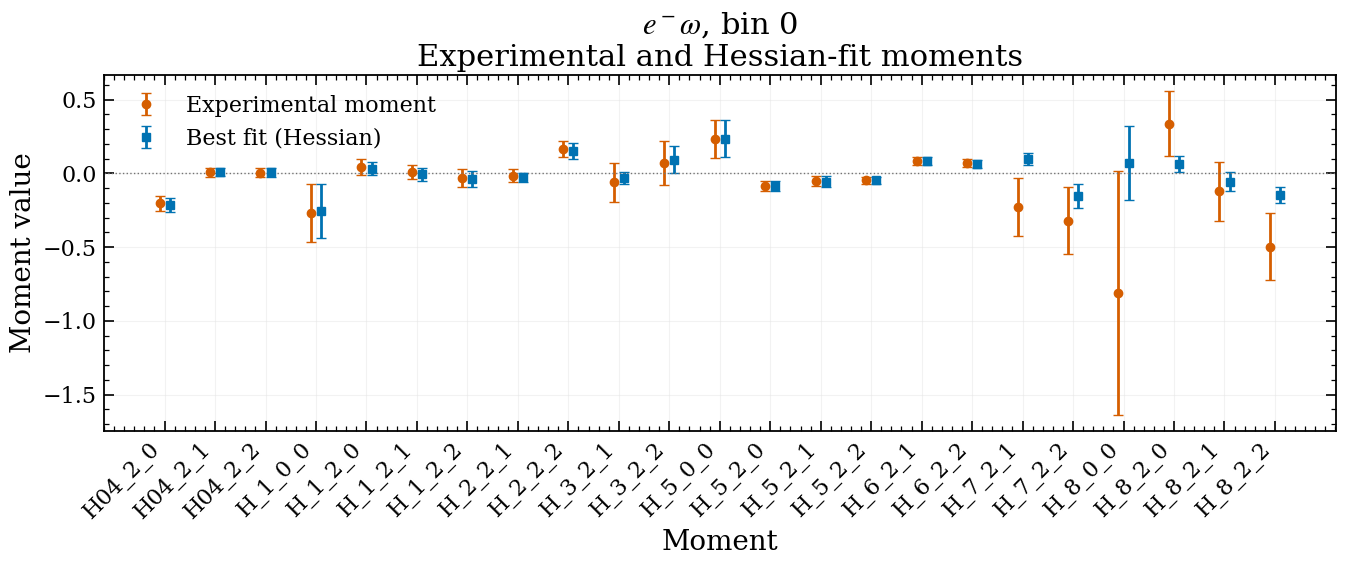

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_analysis_outputs/ElOmega_results_0/ElOmega_results_0_official_vs_hessian_moments.png
ElOmega_results_1: selected entry 80722 / 100000; chi2=3.1242325; cov_status=3


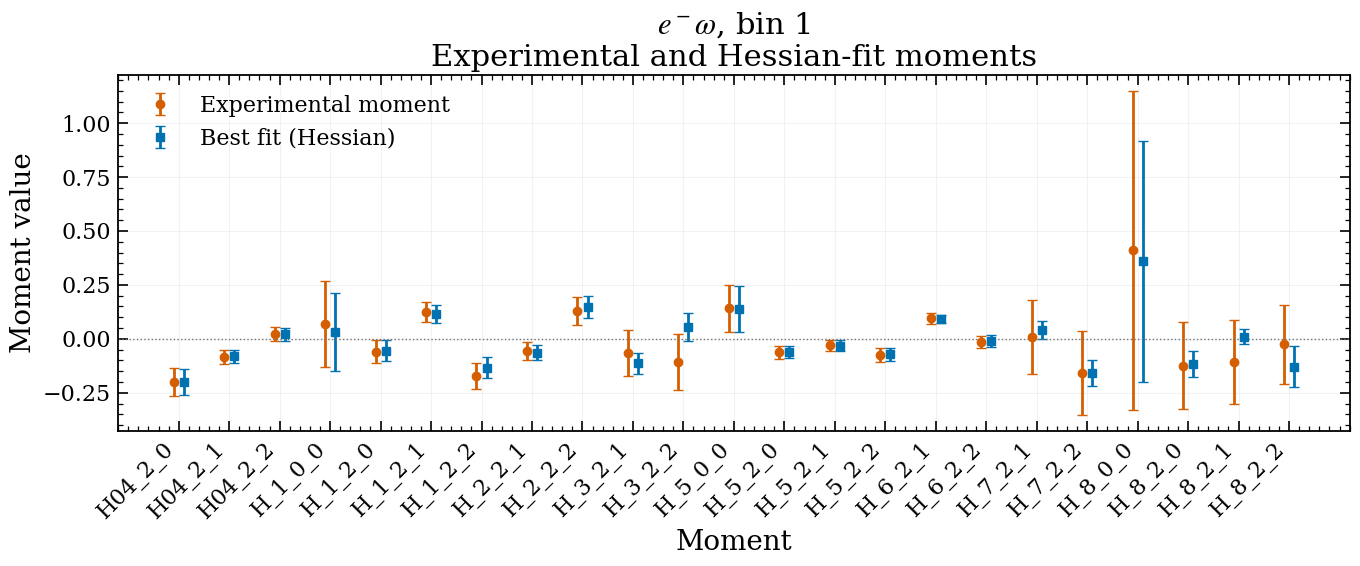

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_analysis_outputs/ElOmega_results_1/ElOmega_results_1_official_vs_hessian_moments.png
ElOmega_results_2: selected entry 16963 / 100000; chi2=12.729017; cov_status=3


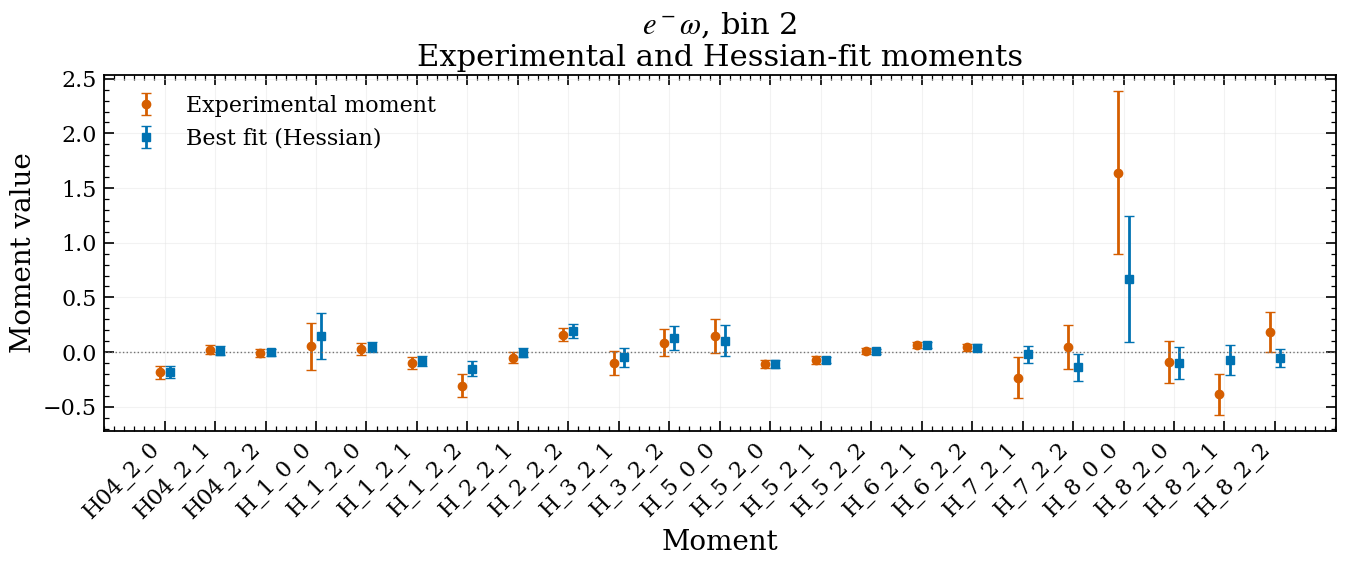

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_analysis_outputs/ElOmega_results_2/ElOmega_results_2_official_vs_hessian_moments.png
ElPhi_results_0: selected entry 2327 / 100000; chi2=6.8981436; cov_status=3


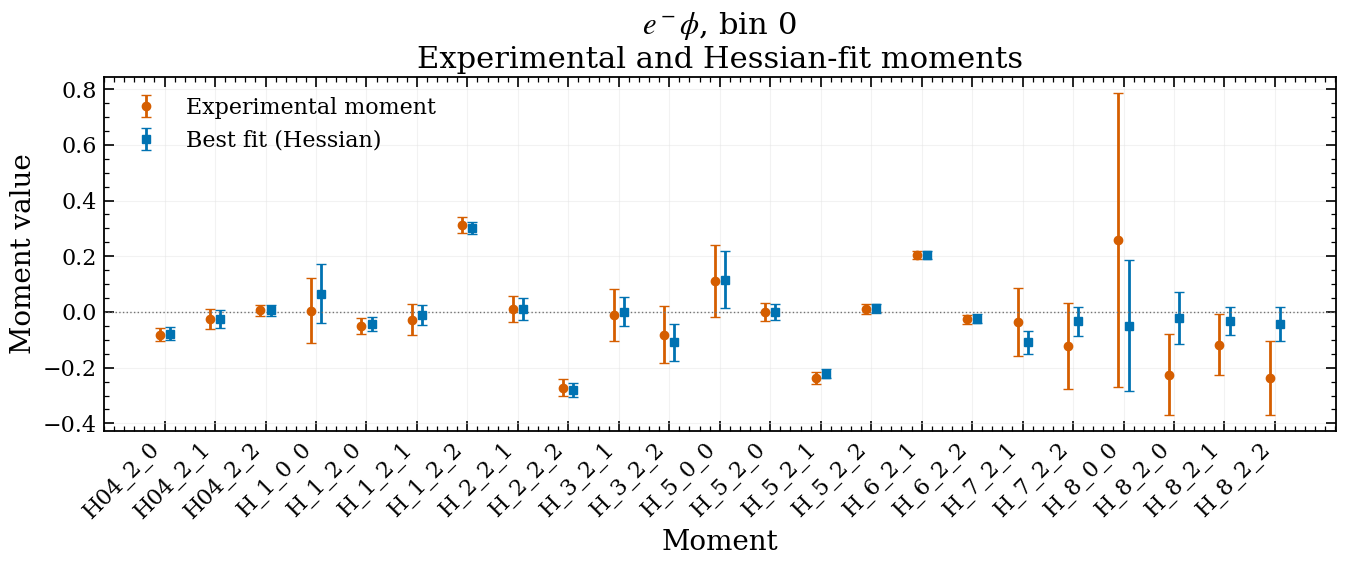

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_analysis_outputs/ElPhi_results_0/ElPhi_results_0_official_vs_hessian_moments.png
ElPhi_results_1: selected entry 11284 / 100000; chi2=3.7093605; cov_status=3


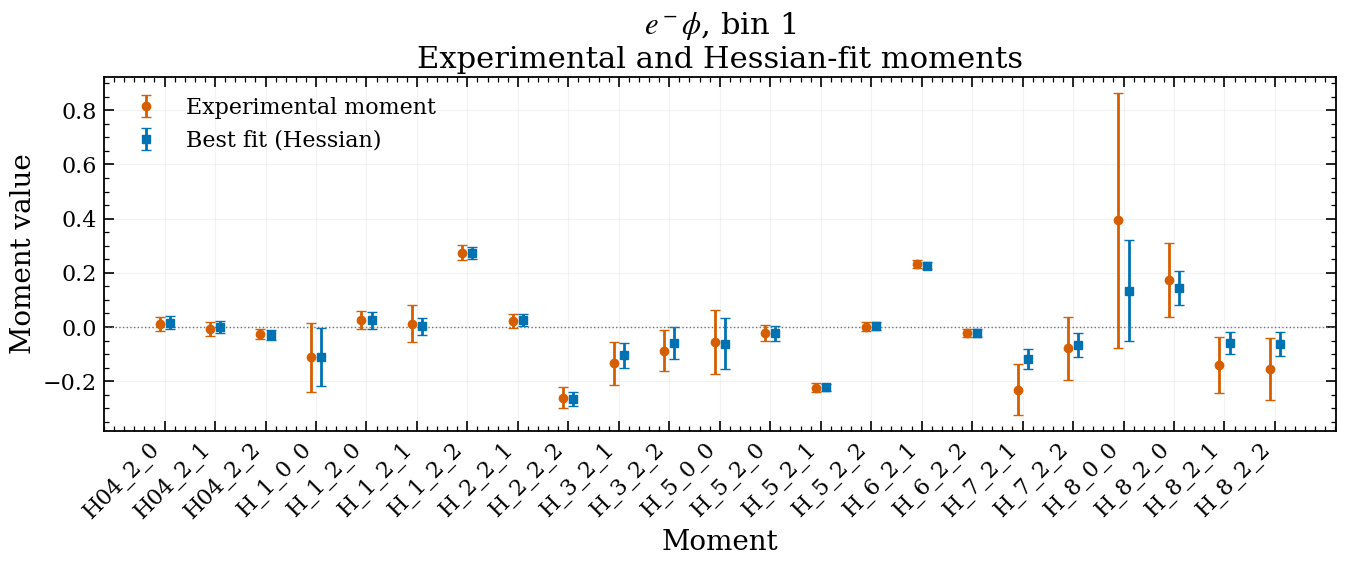

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_analysis_outputs/ElPhi_results_1/ElPhi_results_1_official_vs_hessian_moments.png
ElPhi_results_2: selected entry 50138 / 100000; chi2=10.877955; cov_status=3


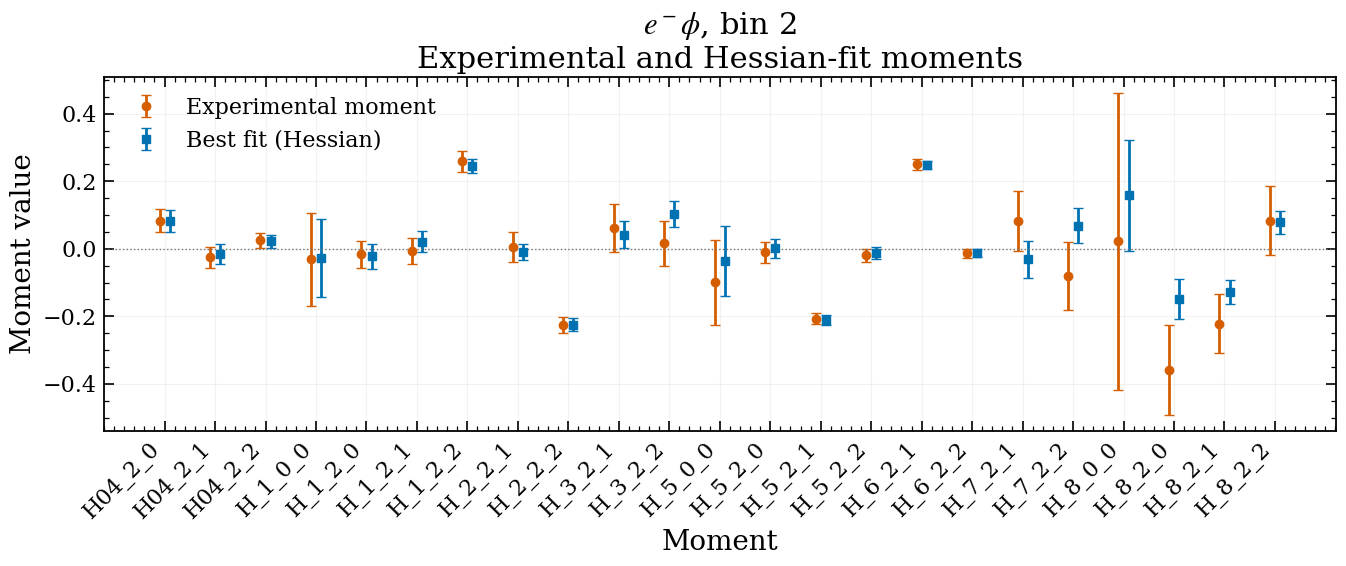

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_analysis_outputs/ElPhi_results_2/ElPhi_results_2_official_vs_hessian_moments.png
ElRho_results_0: selected entry 11209 / 100000; chi2=2.5666462; cov_status=3


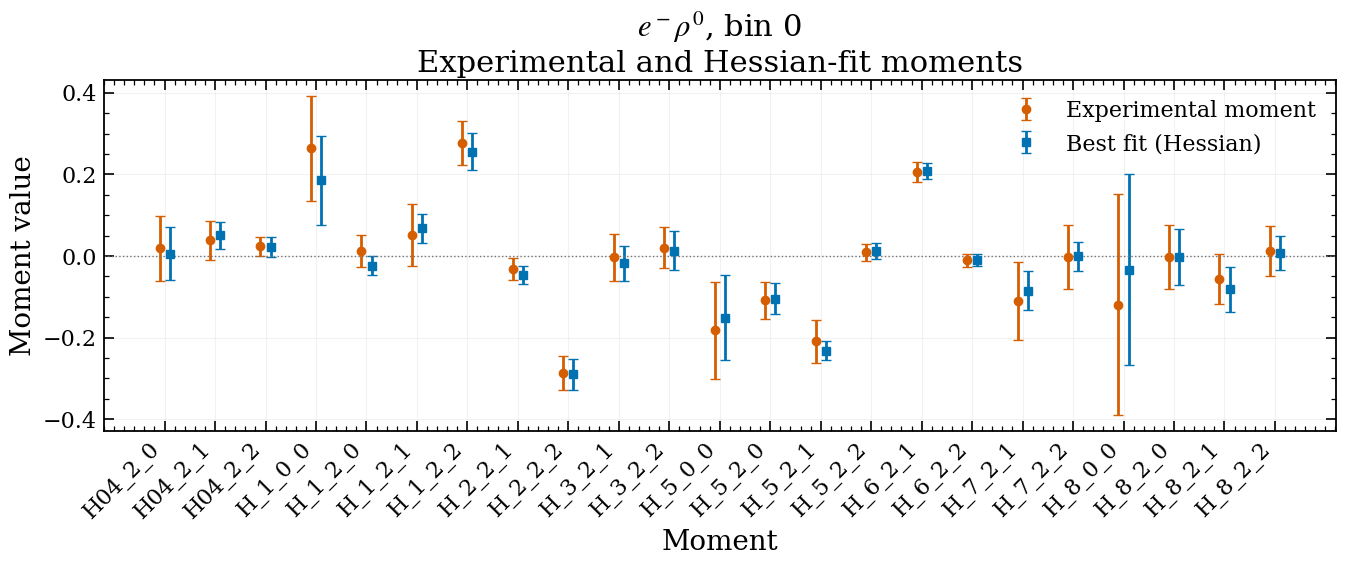

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_analysis_outputs/ElRho_results_0/ElRho_results_0_official_vs_hessian_moments.png
ElRho_results_1: selected entry 16657 / 100000; chi2=4.2057122; cov_status=3


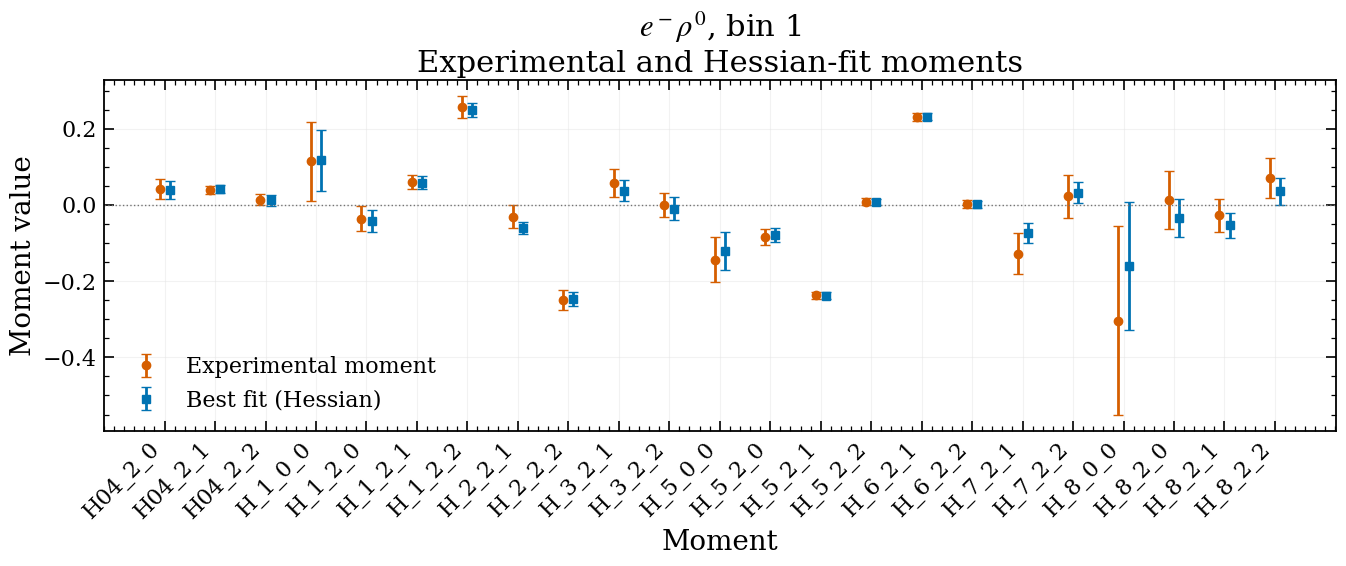

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_analysis_outputs/ElRho_results_1/ElRho_results_1_official_vs_hessian_moments.png
ElRho_results_2: selected entry 6218 / 100000; chi2=3.8768792; cov_status=3


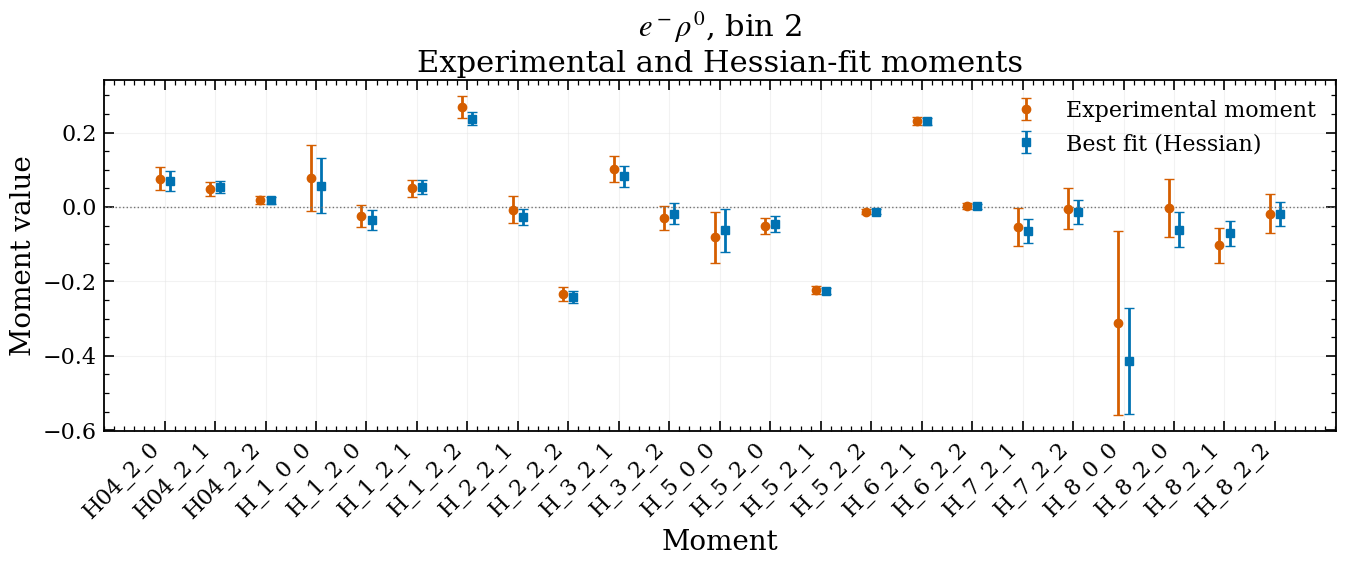

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_analysis_outputs/ElRho_results_2/ElRho_results_2_official_vs_hessian_moments.png
ElRho_results_3: selected entry 82542 / 100000; chi2=8.3715388; cov_status=3


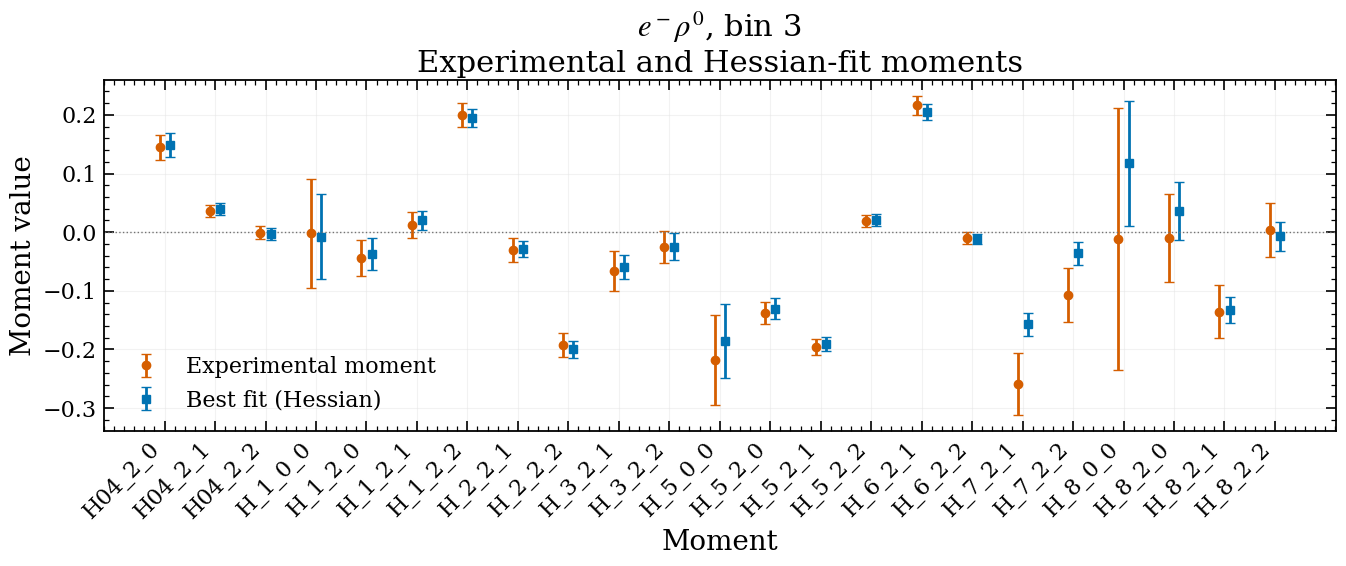

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_analysis_outputs/ElRho_results_3/ElRho_results_3_official_vs_hessian_moments.png
MuOmega_results_0: selected entry 92998 / 100000; chi2=1.9221252; cov_status=3


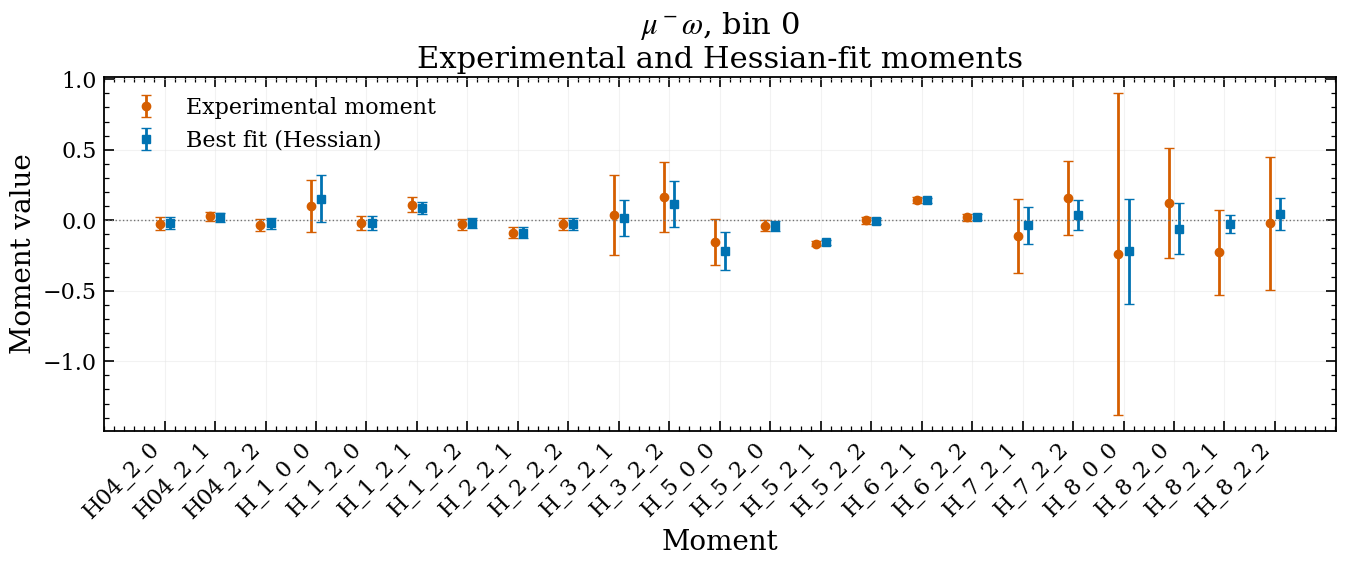

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_analysis_outputs/MuOmega_results_0/MuOmega_results_0_official_vs_hessian_moments.png
MuOmega_results_1: selected entry 87453 / 100000; chi2=1.4379649; cov_status=3


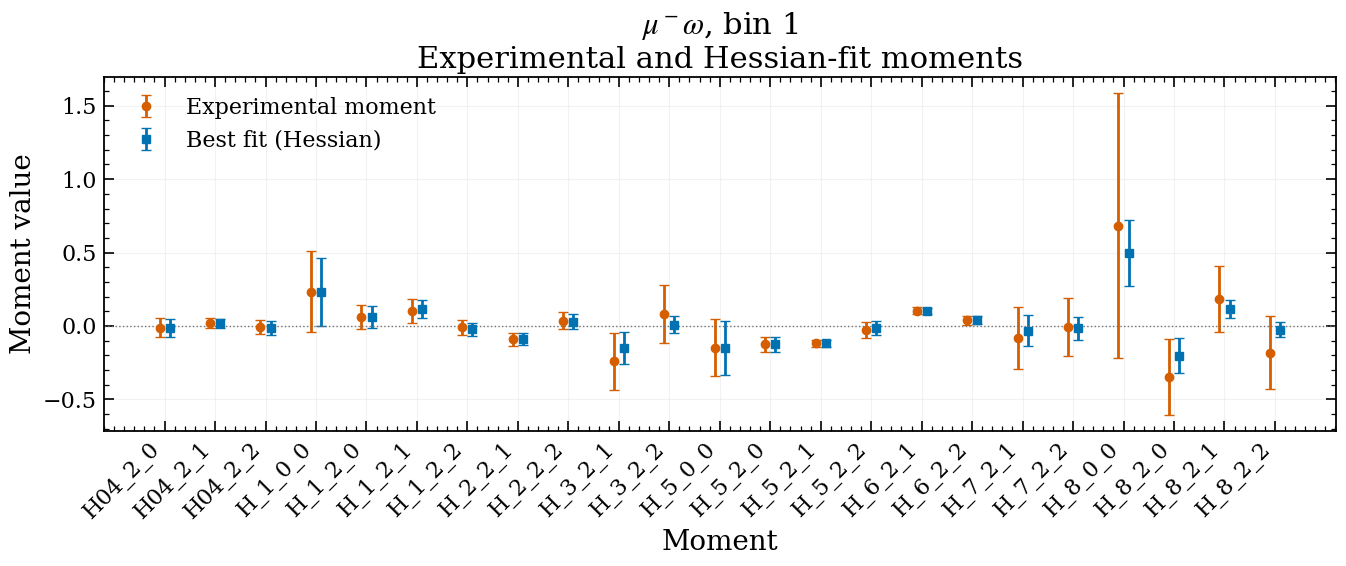

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_analysis_outputs/MuOmega_results_1/MuOmega_results_1_official_vs_hessian_moments.png
MuOmega_results_2: selected entry 9817 / 100000; chi2=5.1430976; cov_status=3


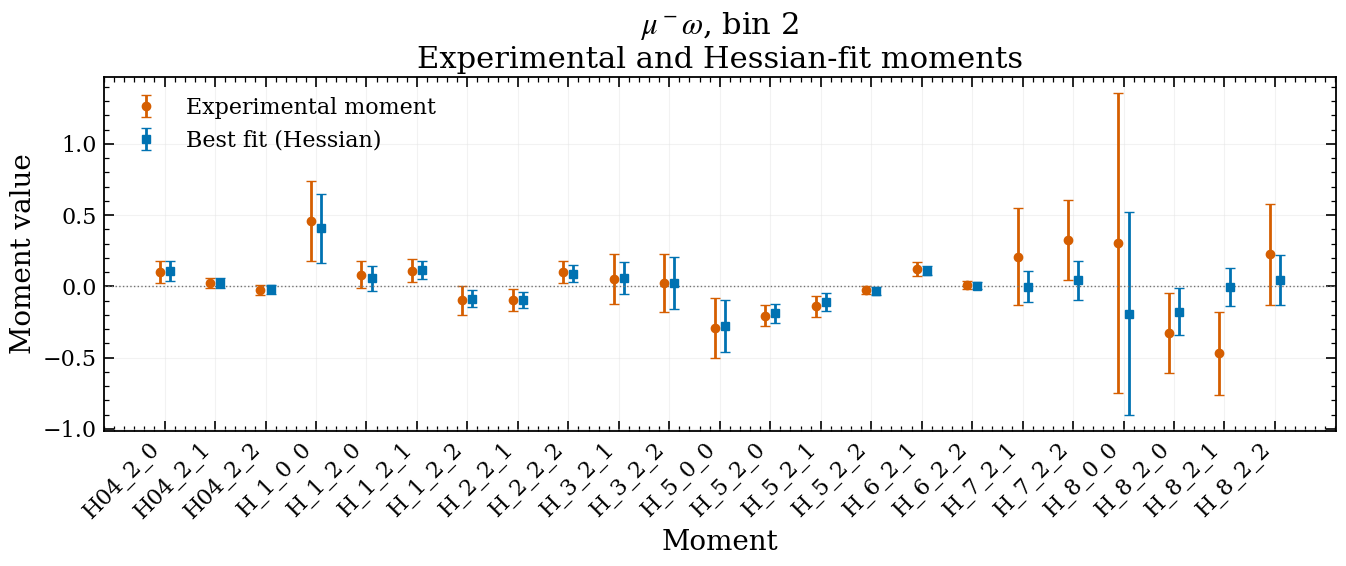

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_analysis_outputs/MuOmega_results_2/MuOmega_results_2_official_vs_hessian_moments.png
MuRho_results_0: selected entry 82110 / 100000; chi2=1.6851471; cov_status=3


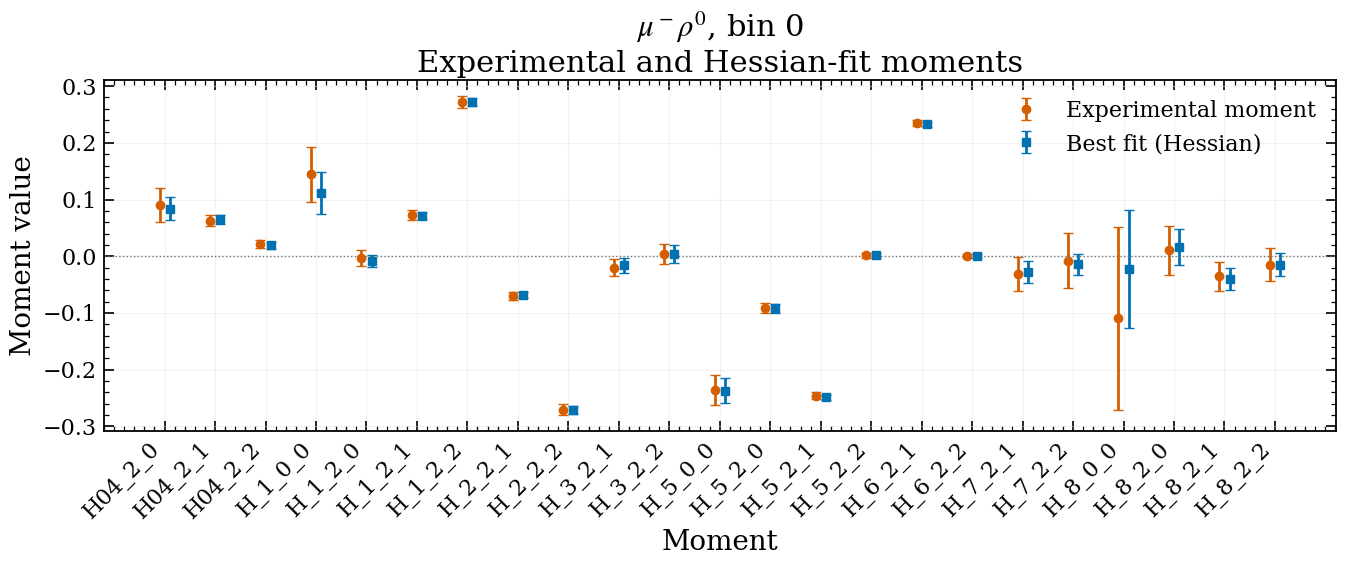

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_analysis_outputs/MuRho_results_0/MuRho_results_0_official_vs_hessian_moments.png
MuRho_results_1: selected entry 20265 / 100000; chi2=7.7701001; cov_status=3


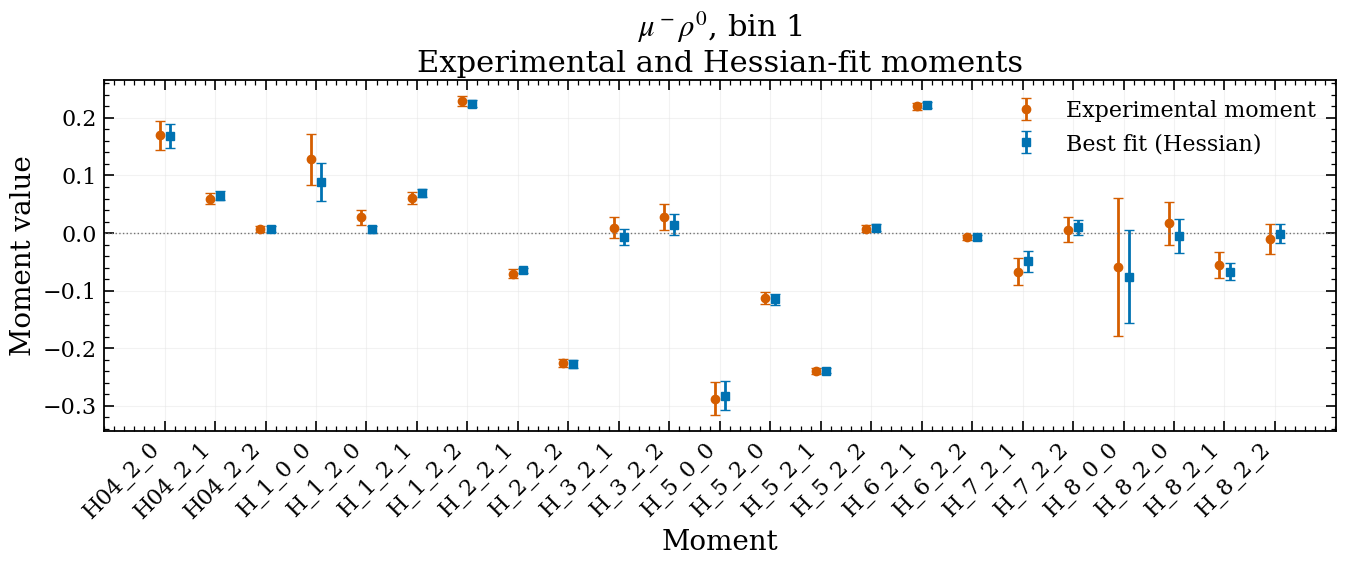

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_analysis_outputs/MuRho_results_1/MuRho_results_1_official_vs_hessian_moments.png
MuRho_results_2: selected entry 1749 / 100000; chi2=14.223758; cov_status=3


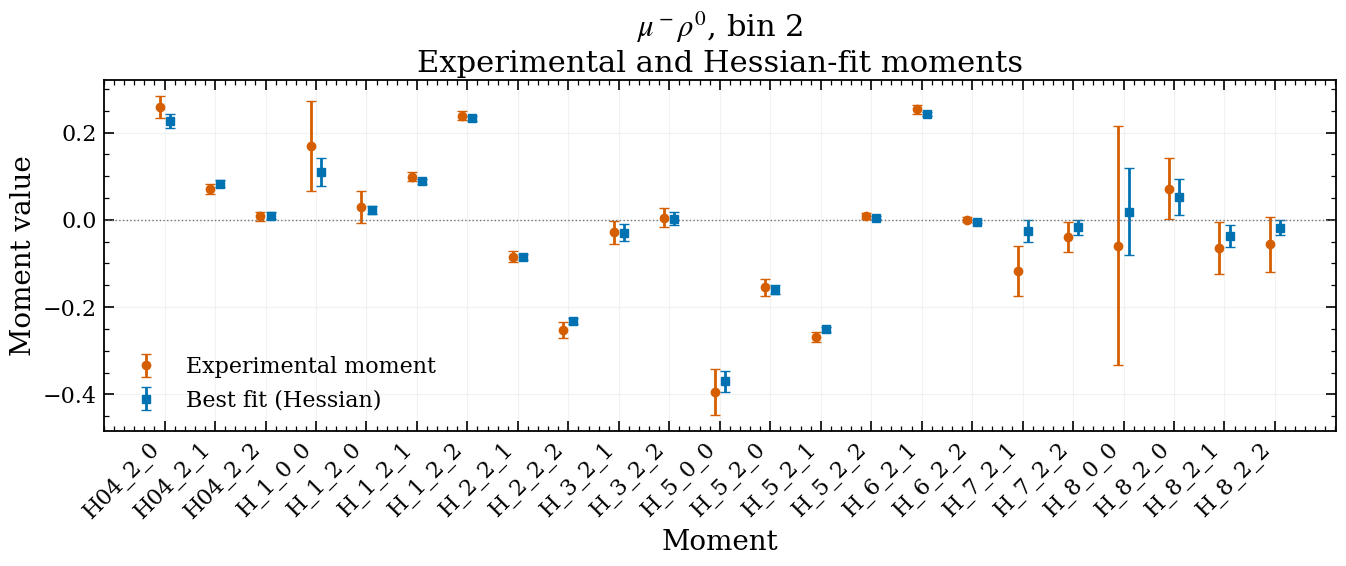

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_analysis_outputs/MuRho_results_2/MuRho_results_2_official_vs_hessian_moments.png
MuRho_results_3: selected entry 11986 / 100000; chi2=7.7750151; cov_status=3


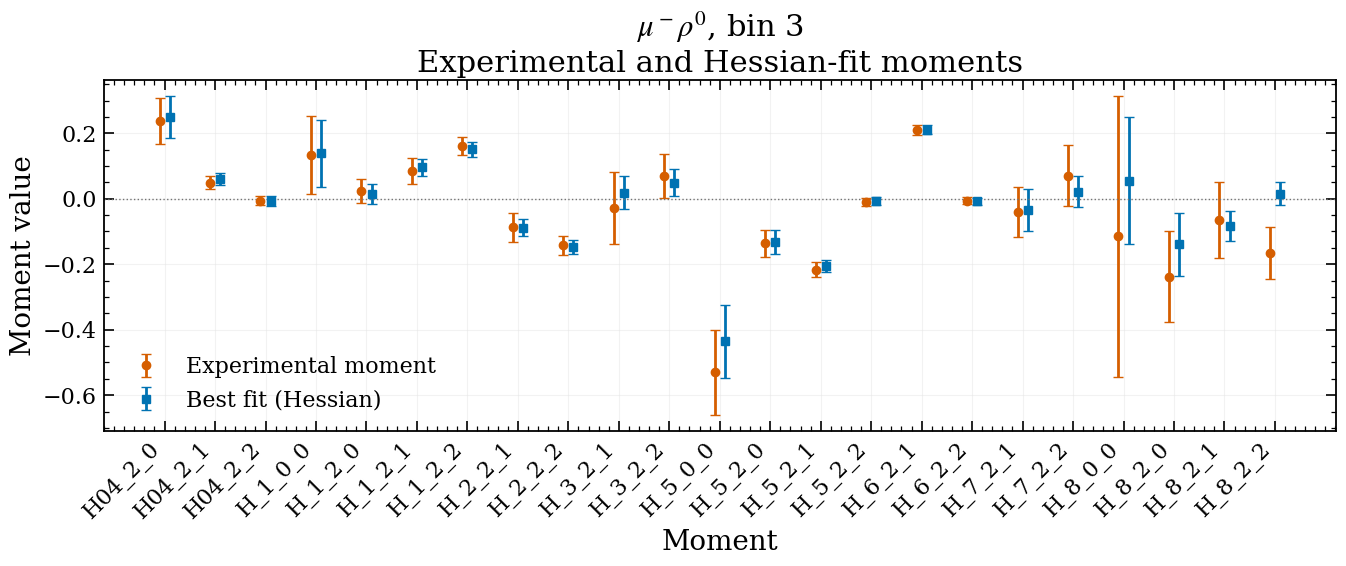

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_analysis_outputs/MuRho_results_3/MuRho_results_3_official_vs_hessian_moments.png


,dataset,file,entries,best_entry,objective_branch,objective_minimum,status,cov_status,edm
0,ElOmega_results_0,/home/dleahy27/Desktop/PhD/Electroproduction/E...,100000,36181,chi2,8.810241,0,3,6.226263e-10
1,ElOmega_results_1,/home/dleahy27/Desktop/PhD/Electroproduction/E...,100000,80722,chi2,3.124233,0,3,2.463797e-12
2,ElOmega_results_2,/home/dleahy27/Desktop/PhD/Electroproduction/E...,100000,16963,chi2,12.729017,0,3,8.207462e-10
3,ElPhi_results_0,/home/dleahy27/Desktop/PhD/Electroproduction/E...,100000,2327,chi2,6.898144,0,3,6.039214e-12
4,ElPhi_results_1,/home/dleahy27/Desktop/PhD/Electroproduction/E...,100000,11284,chi2,3.709360,0,3,1.310938e-12
5,ElPhi_results_2,/home/dleahy27/Desktop/PhD/Electroproduction/E...,100000,50138,chi2,10.877955,0,3,2.698702e-12
6,ElRho_results_0,/home/dleahy27/Desktop/PhD/Electroproduction/E...,100000,11209,chi2,2.566646,0,3,8.290548e-12
7,ElRho_results_1,/home/dleahy27/Desktop/PhD/Electroproduction/E...,100000,16657,chi2,4.205712,0,3,8.434523e-12
8,ElRho_results_2,/home/dleahy27/Desktop/PhD/Electroproduction/E...,100000,6218,chi2,3.876879,0,3,2.420366e-12
9,ElRho_results_3,/home/dleahy27/Desktop/PhD/Electroproduction/E...,100000,82542,chi2,8.371539,0,3,1.396422e-09


In [4]:
def official_branch_candidates(moment):
    if moment.startswith("H04"):
        observed = "RH04" + moment[3:]
    elif moment.startswith("H_"):
        observed = "RH_" + moment[2:]
    else:
        observed = "R" + moment
    return [observed, moment]


def compare_to_official(best, official_moments):
    rows = []
    for moment, (official, official_sigma) in official_moments.items():
        branch = next((name for name in official_branch_candidates(moment)
                       if name in best.index), None)
        if branch is None:
            continue
        error_branch = f"err__{branch}"
        if error_branch not in best.index:
            continue
        fitted = float(best[branch])
        fitted_sigma = float(best[error_branch])
        combined_sigma = np.hypot(official_sigma, fitted_sigma)
        rows.append({
            "moment": moment,
            "branch_used": branch,
            "official": official,
            "official_sigma": official_sigma,
            "hessian_fit": fitted,
            "hessian_sigma": fitted_sigma,
            "delta": fitted - official,
            "pull_combined": (fitted - official) / combined_sigma
                             if combined_sigma > 0 else np.nan,
        })
    return pd.DataFrame(rows)


def plot_objective(frame, best_index, title, key, out_dir):
    objective = objective_column(frame)
    values = pd.to_numeric(frame[objective], errors="coerce").to_numpy(dtype=float)
    fig, ax = plt.subplots(figsize=(8.2, 4.8))
    ax.scatter(np.arange(len(values)), values, s=13, alpha=0.55,
               color=COLORS["fit"], edgecolors="none")
    ax.scatter([best_index], [values[best_index]], marker="*", s=170,
               color=COLORS["official"], edgecolor="black", linewidth=0.6,
               label="Selected global minimum", zorder=5)
    ax.set_xlabel("Minimisation start index")
    ax.set_ylabel(r"$\chi^2_{\min}$" if objective == "chi2" else objective.replace("_", r"_"))
    ax.set_title(title + "\nOrdinary random-start minimisations")
    ax.legend(frameon=False)
    style_axis(ax, grid=True)
    fig.tight_layout()
    save_figure(fig, out_dir / f"{key}_minimisation_objectives.png")


def plot_parameters(best, title, key, out_dir):
    parameters = [name for name in best.index
                  if (MAG_RE.match(name) or PHASE_RE.match(name))
                  and f"err__{name}" in best.index]
    if not parameters:
        return
    x = np.arange(len(parameters))
    values = np.array([float(best[name]) for name in parameters])
    errors = np.array([float(best[f"err__{name}"]) for name in parameters])
    fig, ax = plt.subplots(figsize=(max(11, 0.50 * len(parameters)), 5.5))
    ax.errorbar(x, values, yerr=errors, fmt="o", capsize=3.5,
                color=COLORS["fit"], elinewidth=1.8)
    labels = [name.replace("_", r"_") for name in parameters]
    ax.set_xticks(x, labels, rotation=55, ha="right")
    ax.set_xlabel("Fitted amplitude parameter")
    ax.set_ylabel("Best-fit value")
    ax.set_title(title + "\nBest fit with Hessian uncertainties")
    style_axis(ax, grid=True)
    fig.tight_layout()
    save_figure(fig, out_dir / f"{key}_hessian_parameters.png")


def plot_official_comparison(comparison, title, key, out_dir):
    if comparison.empty:
        return
    table = comparison.sort_values("moment").reset_index(drop=True)
    x = np.arange(len(table))
    fig, ax = plt.subplots(figsize=(max(11, 0.60 * len(table)), 6.0))
    ax.errorbar(x - 0.10, table["official"], yerr=table["official_sigma"],
                fmt="o", capsize=3.5, color=COLORS["official"],
                label="Experimental moment")
    ax.errorbar(x + 0.10, table["hessian_fit"], yerr=table["hessian_sigma"],
                fmt="s", capsize=3.5, color=COLORS["fit"],
                label="Best fit (Hessian)")
    ax.axhline(0, ls=":", color="0.45", lw=1)
    ax.set_xticks(x, [name.replace("_", r"_") for name in table["moment"]],
                  rotation=45, ha="right")
    ax.set_xlabel("Moment")
    ax.set_ylabel("Moment value")
    ax.set_title(title + "\nExperimental and Hessian-fit moments")
    ax.legend(frameon=False)
    style_axis(ax, grid=True)
    fig.tight_layout()
    save_figure(fig, out_dir / f"{key}_official_vs_hessian_moments.png")

    # fig, ax = plt.subplots(figsize=(max(11, 0.60 * len(table)), 5.2))
    # ax.bar(x, table["pull_combined"], color=COLORS["fit"], alpha=0.88)
    # for level, linestyle in [(0, "-"), (1, "--"), (-1, "--"), (2, ":"), (-2, ":")]:
    #     ax.axhline(level, ls=linestyle, color="0.35", lw=1)
    # ax.set_xticks(x, [name.replace("_", r"_") for name in table["moment"]],
    #               rotation=45, ha="right")
    # ax.set_xlabel("Moment")
    # ax.set_ylabel("Combined pull")
    # ax.set_title(title + "\nPulls of Hessian-fit moments")
    # style_axis(ax, grid=True)
    # fig.tight_layout()
    # save_figure(fig, out_dir / f"{key}_official_hessian_moment_pulls.png")


def plot_argand(best, title, key, out_dir):
    pairs = amplitude_pairs(best.index)
    if not pairs:
        return
    fig, ax = plt.subplots(figsize=(7.4, 7.0))
    cmap = mpl.colormaps["tab20"]
    for index, (mag_name, phase_name) in enumerate(pairs):
        mag = float(best[mag_name])
        phase = float(best[phase_name])
        centre = (mag * np.cos(phase), mag * np.sin(phase))
        covariance_mag_phase = covariance_matrix(best, [mag_name, phase_name])
        covariance_xy = transformed_argand_covariance(mag, phase, covariance_mag_phase)
        color = cmap(index % 20)
        add_covariance_ellipse(ax, centre, covariance_xy, color)
        ax.scatter(*centre, s=48, color=color, edgecolor="black", linewidth=0.5,
                   label=wave_label(mag_name), zorder=5)
    ax.axhline(0, color="0.72", lw=1, zorder=0)
    ax.axvline(0, color="0.72", lw=1, zorder=0)
    ax.set_xlabel(r"Real part $\operatorname{Re}A$")
    ax.set_ylabel(r"Imaginary part $\operatorname{Im}A$")
    ax.set_title(title + "\n" + r"Best-fit amplitudes and $1\sigma$ Hessian ellipses")
    ax.set_aspect("equal", adjustable="datalim")
    ax.legend(frameon=False, fontsize=8, ncol=2)
    style_axis(ax)
    fig.tight_layout()
    save_figure(fig, out_dir / f"{key}_hessian_argand.png")


def plot_amplitude_correlation(best, title, key, out_dir):
    parameters = [name for name in best.index if MAG_RE.match(name) or PHASE_RE.match(name)]
    if not parameters:
        return
    covariance = covariance_matrix(best, parameters)
    sigma = np.sqrt(np.clip(np.diag(covariance), 0.0, None))
    denominator = np.outer(sigma, sigma)
    correlation = np.divide(covariance, denominator,
                            out=np.full_like(covariance, np.nan),
                            where=denominator > 0)
    size = max(8, 0.38 * len(parameters) + 4)
    fig, ax = plt.subplots(figsize=(size, size))
    image = ax.imshow(correlation, vmin=-1, vmax=1, cmap="RdBu_r", aspect="equal")
    labels = [name.replace("_", r"_") for name in parameters]
    ticks = np.arange(len(parameters))
    ax.set_xticks(ticks, labels, rotation=90, fontsize=8)
    ax.set_yticks(ticks, labels, fontsize=8)
    ax.set_xlabel("Amplitude parameter")
    ax.set_ylabel("Amplitude parameter")
    ax.set_title(title + "\nHessian correlation matrix")
    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    colorbar.set_label("Correlation coefficient")
    fig.tight_layout()
    save_figure(fig, out_dir / f"{key}_hessian_correlations.png")


def analyse_result_file(root_file):
    metadata = dataset_metadata(root_file)
    key = metadata["key"]
    title = metadata["title"]
    out_dir = OUT_DIR / key
    out_dir.mkdir(parents=True, exist_ok=True)

    frame = read_fit_file(root_file, TREE_NAME)
    best_index, best, objective = select_best_minimum(
        frame, require_accurate_covariance=REQUIRE_ACCURATE_COVARIANCE
    )
    print(f"{key}: selected entry {best_index} / {len(frame)}; "
          f"{objective}={float(best[objective]):.8g}; cov_status={int(best['cov_status'])}")

    summary = pd.DataFrame([{
        "dataset": key,
        "file": str(Path(root_file).resolve()),
        "entries": len(frame),
        "best_entry": best_index,
        "objective_branch": objective,
        "objective_minimum": float(best[objective]),
        "status": int(best["status"]),
        "cov_status": int(best["cov_status"]),
        "edm": float(best["edm"]),
    }])

    #plot_objective(frame, best_index, title, key, out_dir)
    #plot_parameters(best, title, key, out_dir)
    #plot_argand(best, title, key, out_dir)
    #plot_amplitude_correlation(best, title, key, out_dir)

    official = OFFICIAL_MOMENTS_BY_DATASET.get(key)
    comparison = pd.DataFrame()
    if official:
        comparison = compare_to_official(best, official)
        comparison.insert(0, "dataset", key)
        plot_official_comparison(comparison, title, key, out_dir)
    else:
        warnings.warn(f"No official moment table is configured for {key}")

    return summary.iloc[0].to_dict()


analysis_index = pd.DataFrame([analyse_result_file(path) for path in ROOT_FILES])
OUT_DIR.mkdir(parents=True, exist_ok=True)
display(analysis_index)
